<div style="background-color: lightgray; padding: 10px;">

<div style="display: flex; align-items: center; gap: 20px;">
        <img src="https://www.rmag.org/graphics/design/RMAG-logo-2022.png" width="100">

<div style="font-weight: bold; font-size: 40px;align-items: center;">
            Python Skill Series
        </div>
    </div>

<div style="
        font-size: 30px;
        text-align: center;
        margin-top: 10px;
    ">Spatial Geoscience &amp; Analytics
</div>

<div style="
        font-size: 30px;
        text-align: center;
        margin-top: 10px;
    ">Well Deviation Surveys
</div>

</div>


In this exercise, we will take a well deviation survey report data with [wellpathpy](https://wellpathpy.readthedocs.io/en/latest/tutorial.html) and resample it on a higher resolution for merging to a wireline log and produce GIS files.


***All** documents provided are public and available through [ECMC: Wakeman #20-17-1NAH ](https://ecmc.state.co.us/cogisdb/Resources/Docs?classid=07~08&id=00110397)*

In [1]:
import pandas as pd
import geopandas as gpd
import wellpathpy as wp
from shapely import Point, LineString
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
# Pasted in from the original well plan (like a survey) document with manual corrections already made.
lines = '''0.00† 0.000 259.083 0.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
16.00 0.000 259.083 16.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00 Tie On
116.00† 0.000 259.083 116.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
216.00† 0.000 259.083 216.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
316.00† 0.000 259.083 316.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
416.00† 0.000 259.083 416.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
516.00† 0.000 259.083 516.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
616.00† 0.000 259.083 616.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
716.00† 0.000 259.083 716.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
816.00† 0.000 259.083 816.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00
900.00 0.000 259.083 900.00 0.00 0.00 0.00 39°56'38.637"N 104°41'10.605"W 0.00 End of Tangent
916.00† 0.320 259.083 916.00 0.00 -0.01 -0.04 39°56'38.637"N 104°41'10.605"W 2.00
1016.00† 2.320 259.083 1015.97 0.16 -0.44 -2.31 39°56'38.633"N 104°41'10.634"W 2.00
1116.00† 4.320 259.083 1115.80 0.56 -1.54 -7.99 39°56'38.623"N 104°41'10.708"W 2.00
1216.00† 6.320 259.083 1215.36 1.19 -3.30 -17.10 39°56'38.606"N 104°41'10.825"W 2.00
1316.00† 8.320 259.083 1314.54 2.07 -5.71 -29.61 39°56'38.583"N 104°41'10.986"W 2.00
1416.00† 10.320 259.083 1413.21 3.18 -8.78 -45.51 39°56'38.555"N 104°41'11.190"W 2.00
1504.48† 12.090 259.083 1500.00 4.36 -12.03 -62.39 39°56'38.524"N 104°41'11.407"W 2.00 FOX HILLS
1516.00† 12.320 259.083 1511.26 4.53 -12.49 -64.78 39°56'38.520"N 104°41'11.438"W 2.00
1616.00† 14.320 259.083 1608.57 6.11 -16.86 -87.40 39°56'38.479"N 104°41'11.729"W 2.00
1716.00† 16.320 259.083 1705.01 7.92 -21.86 -113.34 39°56'38.431"N 104°41'12.062"W 2.00
1816.00† 18.320 259.083 1800.47 9.97 -27.50 -142.57 39°56'38.378"N 104°41'12.438"W 2.00
1916.00† 20.320 259.083 1894.84 12.24 -33.76 -175.06 39°56'38.319"N 104°41'12.856"W 2.00
2008.08 22.162 259.083 1980.66 14.53 -40.08 -207.81 39°56'38.260"N 104°41'13.277"W 2.00 End of Build (XS)
2016.00† 22.162 259.083 1987.99 14.73 -40.65 -210.74 39°56'38.255"N 104°41'13.315"W 0.00
2116.00† 22.162 259.083 2080.60 17.32 -47.79 -247.78 39°56'38.187"N 104°41'13.792"W 0.00
2216.00† 22.162 259.083 2173.22 19.91 -54.94 -284.82 39°56'38.120"N 104°41'14.268"W 0.00
2316.00† 22.162 259.083 2265.83 22.50 -62.08 -321.86 39°56'38.053"N 104°41'14.744"W 0.00
2416.00† 22.162 259.083 2358.44 25.09 -69.22 -358.90 39°56'37.986"N 104°41'15.221"W 0.00
2516.00† 22.162 259.083 2451.05 27.67 -76.37 -395.94 39°56'37.918"N 104°41'15.697"W 0.00
2616.00† 22.162 259.083 2543.66 30.26 -83.51 -432.98 39°56'37.851"N 104°41'16.173"W 0.00
2716.00† 22.162 259.083 2636.28 32.85 -90.66 -470.02 39°56'37.784"N 104°41'16.650"W 0.00
2816.00† 22.162 259.083 2728.89 35.44 -97.80 -507.06 39°56'37.717"N 104°41'17.126"W 0.00
2916.00† 22.162 259.083 2821.50 38.03 -104.94 -544.10 39°56'37.649"N 104°41'17.603"W 0.00
3016.00† 22.162 259.083 2914.11 40.62 -112.09 -581.14 39°56'37.582"N 104°41'18.079"W 0.00
3116.00† 22.162 259.083 3006.73 43.21 -119.23 -618.18 39°56'37.515"N 104°41'18.555"W 0.00
3216.00† 22.162 259.083 3099.34 45.80 -126.38 -655.22 39°56'37.448"N 104°41'19.032"W 0.00
3316.00† 22.162 259.083 3191.95 48.39 -133.52 -692.26 39°56'37.380"N 104°41'19.508"W 0.00
3416.00† 22.162 259.083 3284.56 50.97 -140.66 -729.30 39°56'37.313"N 104°41'19.984"W 0.00
3516.00† 22.162 259.083 3377.18 53.56 -147.81 -766.34 39°56'37.246"N 104°41'20.461"W 0.00
3616.00† 22.162 259.083 3469.79 56.15 -154.95 -803.38 39°56'37.179"N 104°41'20.937"W 0.00
3716.00† 22.162 259.083 3562.40 58.74 -162.10 -840.42 39°56'37.111"N 104°41'21.414"W 0.00
3816.00† 22.162 259.083 3655.01 61.33 -169.24 -877.45 39°56'37.044"N 104°41'21.890"W 0.00
3916.00† 22.162 259.083 3747.62 63.92 -176.38 -914.49 39°56'36.977"N 104°41'22.366"W 0.00
4016.00† 22.162 259.083 3840.24 66.51 -183.53 -951.53 39°56'36.910"N 104°41'22.843"W 0.00
4116.00† 22.162 259.083 3932.85 69.10 -190.67 -988.57 39°56'36.842"N 104°41'23.319"W 0.00
4216.00† 22.162 259.083 4025.46 71.69 -197.82 -1025.61 39°56'36.775"N 104°41'23.795"W 0.00
4316.00† 22.162 259.083 4118.07 74.27 -204.96 -1062.65 39°56'36.708"N 104°41'24.272"W 0.00
4416.00† 22.162 259.083 4210.69 76.86 -212.11 -1099.69 39°56'36.641"N 104°41'24.748"W 0.00
4516.00† 22.162 259.083 4303.30 79.45 -219.25 -1136.73 39°56'36.573"N 104°41'25.225"W 0.00
4616.00† 22.162 259.083 4395.91 82.04 -226.39 -1173.77 39°56'36.506"N 104°41'25.701"W 0.00
4716.00† 22.162 259.083 4488.52 84.63 -233.54 -1210.81 39°56'36.439"N 104°41'26.177"W 0.00
4816.00† 22.162 259.083 4581.14 87.22 -240.68 -1247.85 39°56'36.372"N 104°41'26.654"W 0.00
4916.00† 22.162 259.083 4673.75 89.81 -247.83 -1284.89 39°56'36.304"N 104°41'27.130"W 0.00
5016.00† 22.162 259.083 4766.36 92.40 -254.97 -1321.93 39°56'36.237"N 104°41'27.606"W 0.00
5106.31† 22.162 259.083 4850.00 94.74 -261.42 -1355.38 39°56'36.176"N 104°41'28.037"W 0.00 SUSSEX/SHANNON
5116.00† 22.162 259.083 4858.97 94.99 -262.11 -1358.97 39°56'36.170"N 104°41'28.083"W 0.00
5216.00† 22.162 259.083 4951.58 97.57 -269.26 -1396.01 39°56'36.103"N 104°41'28.559"W 0.00
5316.00† 22.162 259.083 5044.20 100.16 -276.40 -1433.05 39°56'36.035"N 104°41'29.035"W 0.00
5416.00† 22.162 259.083 5136.81 102.75 -283.55 -1470.09 39°56'35.968"N 104°41'29.512"W 0.00
5516.00† 22.162 259.083 5229.42 105.34 -290.69 -1507.13 39°56'35.901"N 104°41'29.988"W 0.00
5616.00† 22.162 259.083 5322.03 107.93 -297.83 -1544.17 39°56'35.834"N 104°41'30.465"W 0.00
5716.00† 22.162 259.083 5414.65 110.52 -304.98 -1581.21 39°56'35.766"N 104°41'30.941"W 0.00
5816.00† 22.162 259.083 5507.26 113.11 -312.12 -1618.24 39°56'35.699"N 104°41'31.417"W 0.00
5916.00† 22.162 259.083 5599.87 115.70 -319.27 -1655.28 39°56'35.632"N 104°41'31.894"W 0.00
6016.00† 22.162 259.083 5692.48 118.29 -326.41 -1692.32 39°56'35.565"N 104°41'32.370"W 0.00
6116.00† 22.162 259.083 5785.10 120.88 -333.55 -1729.36 39°56'35.497"N 104°41'32.846"W 0.00
6216.00† 22.162 259.083 5877.71 123.46 -340.70 -1766.40 39°56'35.430"N 104°41'33.323"W 0.00
6316.00† 22.162 259.083 5970.32 126.05 -347.84 -1803.44 39°56'35.363"N 104°41'33.799"W 0.00
6416.00† 22.162 259.083 6062.93 128.64 -354.99 -1840.48 39°56'35.295"N 104°41'34.276"W 0.00
6516.00† 22.162 259.083 6155.54 131.23 -362.13 -1877.52 39°56'35.228"N 104°41'34.752"W 0.00
6616.00† 22.162 259.083 6248.16 133.82 -369.27 -1914.56 39°56'35.161"N 104°41'35.228"W 0.00
6716.00† 22.162 259.083 6340.77 136.41 -376.42 -1951.60 39°56'35.094"N 104°41'35.705"W 0.00
6816.00† 22.162 259.083 6433.38 139.00 -383.56 -1988.64 39°56'35.026"N 104°41'36.181"W 0.00
6916.00† 22.162 259.083 6525.99 141.59 -390.71 -2025.68 39°56'34.959"N 104°41'36.657"W 0.00
7016.00† 22.162 259.083 6618.61 144.18 -397.85 -2062.72 39°56'34.892"N 104°41'37.134"W 0.00
7068.12 22.162 259.083 6666.88 145.52 -401.57 -2082.02 39°56'34.857"N 104°41'37.382"W 0.00 End of Tangent (XS)
7116.00† 21.953 271.843 6711.28 148.72 -403.00 -2099.85 39°56'34.844"N 104°41'37.611"W 10.00
7216.00† 24.563 296.487 6803.36 167.86 -393.10 -2137.23 39°56'34.946"N 104°41'38.090"W 10.00
7316.00† 30.244 314.516 6892.26 203.35 -366.11 -2173.88 39°56'35.216"N 104°41'38.557"W 10.00
7416.00† 37.625 326.682 6975.26 254.11 -322.83 -2208.69 39°56'35.646"N 104°41'38.999"W 10.00
7516.00† 45.886 335.184 7049.86 318.58 -264.59 -2240.61 39°56'36.225"N 104°41'39.402"W 10.00
7616.00† 54.619 341.540 7113.77 394.81 -193.16 -2268.65 39°56'36.933"N 104°41'39.754"W 10.00
7716.00† 63.619 346.630 7165.07 480.50 -110.70 -2291.98 39°56'37.750"N 104°41'40.044"W 10.00
7816.00† 72.773 350.973 7202.19 573.02 -19.73 -2309.88 39°56'38.651"N 104°41'40.263"W 10.00
7916.00† 82.011 354.902 7224.00 669.57 77.00 -2321.80 39°56'39.608"N 104°41'40.405"W 10.00
8002.15 90.000 358.138 7230.001 753.75 162.71 -2327.00 39°56'40.455"N 104°41'40.461"W 10.00 End of 3D Arc (XS)
8016.00† 90.000 358.138 7230.00 767.24 176.55 -2327.45 39°56'40.592"N 104°41'40.465"W 0.00
8116.00† 90.000 358.138 7230.00 864.68 276.49 -2330.70 39°56'41.580"N 104°41'40.496"W 0.00
8216.00† 90.000 358.138 7230.00 962.12 376.44 -2333.95 39°56'42.568"N 104°41'40.526"W 0.00
8316.00† 90.000 358.138 7230.00 1059.56 476.39 -2337.20 39°56'43.556"N 104°41'40.556"W 0.00
8416.00† 90.000 358.138 7230.00 1157.00 576.34 -2340.45 39°56'44.544"N 104°41'40.586"W 0.00
8516.00† 90.000 358.138 7230.00 1254.45 676.28 -2343.70 39°56'45.532"N 104°41'40.616"W 0.00
8616.00† 90.000 358.138 7230.00 1351.89 776.23 -2346.95 39°56'46.520"N 104°41'40.646"W 0.00
8716.00† 90.000 358.138 7230.00 1449.33 876.18 -2350.20 39°56'47.508"N 104°41'40.676"W 0.00
8816.00† 90.000 358.138 7230.00 1546.77 976.13 -2353.45 39°56'48.496"N 104°41'40.706"W 0.00
8916.00† 90.000 358.138 7230.00 1644.21 1076.07 -2356.70 39°56'49.484"N 104°41'40.736"W 0.00
9016.00† 90.000 358.138 7230.00 1741.65 1176.02 -2359.95 39°56'50.472"N 104°41'40.766"W 0.00
9116.00† 90.000 358.138 7230.00 1839.09 1275.97 -2363.20 39°56'51.460"N 104°41'40.796"W 0.00
9216.00† 90.000 358.138 7230.00 1936.53 1375.91 -2366.45 39°56'52.448"N 104°41'40.826"W 0.00
9316.00† 90.000 358.138 7230.00 2033.97 1475.86 -2369.70 39°56'53.435"N 104°41'40.856"W 0.00
9416.00† 90.000 358.138 7230.00 2131.41 1575.81 -2372.94 39°56'54.423"N 104°41'40.886"W 0.00
9516.00† 90.000 358.138 7230.00 2228.85 1675.76 -2376.19 39°56'55.411"N 104°41'40.916"W 0.00
9616.00† 90.000 358.138 7230.00 2326.30 1775.70 -2379.44 39°56'56.399"N 104°41'40.947"W 0.00
9716.00† 90.000 358.138 7230.00 2423.74 1875.65 -2382.69 39°56'57.387"N 104°41'40.977"W 0.00
9816.00† 90.000 358.138 7230.00 2521.18 1975.60 -2385.94 39°56'58.375"N 104°41'41.007"W 0.00
9916.00† 90.000 358.138 7230.00 2618.62 2075.54 -2389.19 39°56'59.363"N 104°41'41.037"W 0.00
10016.00† 90.000 358.138 7230.00 2716.06 2175.49 -2392.44 39°57'00.351"N 104°41'41.067"W 0.00
10116.00† 90.000 358.138 7230.00 2813.50 2275.44 -2395.69 39°57'01.339"N 104°41'41.097"W 0.00
10216.00† 90.000 358.138 7230.00 2910.94 2375.39 -2398.94 39°57'02.327"N 104°41'41.127"W 0.00
10316.00† 90.000 358.138 7230.00 3008.38 2475.33 -2402.19 39°57'03.315"N 104°41'41.157"W 0.00
10416.00† 90.000 358.138 7230.00 3105.82 2575.28 -2405.44 39°57'04.303"N 104°41'41.187"W 0.00
10516.00† 90.000 358.138 7230.00 3203.26 2675.23 -2408.69 39°57'05.291"N 104°41'41.217"W 0.00
10616.00† 90.000 358.138 7230.00 3300.70 2775.17 -2411.94 39°57'06.279"N 104°41'41.247"W 0.00
10716.00† 90.000 358.138 7230.00 3398.15 2875.12 -2415.19 39°57'07.267"N 104°41'41.277"W 0.00
10816.00† 90.000 358.138 7230.00 3495.59 2975.07 -2418.44 39°57'08.255"N 104°41'41.307"W 0.00
10916.00† 90.000 358.138 7230.00 3593.03 3075.02 -2421.69 39°57'09.243"N 104°41'41.337"W 0.00
11016.00† 90.000 358.138 7230.00 3690.47 3174.96 -2424.94 39°57'10.231"N 104°41'41.368"W 0.00
11116.00† 90.000 358.138 7230.00 3787.91 3274.91 -2428.19 39°57'11.219"N 104°41'41.398"W 0.00
11216.00† 90.000 358.138 7230.00 3885.35 3374.86 -2431.44 39°57'12.207"N 104°41'41.428"W 0.00
11316.00† 90.000 358.138 7230.00 3982.79 3474.80 -2434.69 39°57'13.195"N 104°41'41.458"W 0.00
11416.00† 90.000 358.138 7230.00 4080.23 3574.75 -2437.94 39°57'14.183"N 104°41'41.488"W 0.00
11516.00† 90.000 358.138 7230.00 4177.67 3674.70 -2441.19 39°57'15.171"N 104°41'41.518"W 0.00
11616.00† 90.000 358.138 7230.00 4275.11 3774.65 -2444.44 39°57'16.159"N 104°41'41.548"W 0.00
11716.00† 90.000 358.138 7230.00 4372.55 3874.59 -2447.69 39°57'17.147"N 104°41'41.578"W 0.00
11816.00† 90.000 358.138 7230.00 4470.00 3974.54 -2450.94 39°57'18.135"N 104°41'41.608"W 0.00
11916.00† 90.000 358.138 7230.00 4567.44 4074.49 -2454.19 39°57'19.123"N 104°41'41.638"W 0.00
12016.00† 90.000 358.138 7230.00 4664.88 4174.44 -2457.44 39°57'20.111"N 104°41'41.668"W 0.00
12116.00† 90.000 358.138 7230.00 4762.32 4274.38 -2460.69 39°57'21.099"N 104°41'41.698"W 0.00
12216.00† 90.000 358.138 7230.00 4859.76 4374.33 -2463.93 39°57'22.087"N 104°41'41.728"W 0.00
12316.00† 90.000 358.138 7230.00 4957.20 4474.28 -2467.18 39°57'23.075"N 104°41'41.759"W 0.00
12416.00† 90.000 358.138 7230.00 5054.64 4574.22 -2470.43 39°57'24.063"N 104°41'41.789"W 0.00
12516.00† 90.000 358.138 7230.00 5152.08 4674.17 -2473.68 39°57'25.051"N 104°41'41.819"W 0.00
12616.00† 90.000 358.138 7230.00 5249.52 4774.12 -2476.93 39°57'26.039"N 104°41'41.849"W 0.00
12716.00† 90.000 358.138 7230.00 5346.96 4874.07 -2480.18 39°57'27.026"N 104°41'41.879"W 0.00
12816.00† 90.000 358.138 7230.00 5444.40 4974.01 -2483.43 39°57'28.014"N 104°41'41.909"W 0.00
12916.00† 90.000 358.138 7230.00 5541.85 5073.96 -2486.68 39°57'29.002"N 104°41'41.939"W 0.00
13016.00† 90.000 358.138 7230.00 5639.29 5173.91 -2489.93 39°57'29.990"N 104°41'41.969"W 0.00
13116.00† 90.000 358.138 7230.00 5736.73 5273.85 -2493.18 39°57'30.978"N 104°41'41.999"W 0.00
13216.00† 90.000 358.138 7230.00 5834.17 5373.80 -2496.43 39°57'31.966"N 104°41'42.029"W 0.00
13316.00† 90.000 358.138 7230.00 5931.61 5473.75 -2499.68 39°57'32.954"N 104°41'42.059"W 0.00
13416.00† 90.000 358.138 7230.00 6029.05 5573.70 -2502.93 39°57'33.942"N 104°41'42.089"W 0.00
13516.00† 90.000 358.138 7230.00 6126.49 5673.64 -2506.18 39°57'34.930"N 104°41'42.119"W 0.00
13616.00† 90.000 358.138 7230.00 6223.93 5773.59 -2509.43 39°57'35.918"N 104°41'42.150"W 0.00
13716.00† 90.000 358.138 7230.00 6321.37 5873.54 -2512.68 39°57'36.906"N 104°41'42.180"W 0.00
13816.00† 90.000 358.138 7230.00 6418.81 5973.48 -2515.93 39°57'37.894"N 104°41'42.210"W 0.00
13916.00† 90.000 358.138 7230.00 6516.25 6073.43 -2519.18 39°57'38.882"N 104°41'42.240"W 0.00
14016.00† 90.000 358.138 7230.00 6613.69 6173.38 -2522.43 39°57'39.870"N 104°41'42.270"W 0.00
14116.00† 90.000 358.138 7230.00 6711.14 6273.33 -2525.68 39°57'40.858"N 104°41'42.300"W 0.00
14216.00† 90.000 358.138 7230.00 6808.58 6373.27 -2528.93 39°57'41.846"N 104°41'42.330"W 0.00
14316.00† 90.000 358.138 7230.00 6906.02 6473.22 -2532.18 39°57'42.834"N 104°41'42.360"W 0.00
14416.00† 90.000 358.138 7230.00 7003.46 6573.17 -2535.43 39°57'43.822"N 104°41'42.390"W 0.00
14516.00† 90.000 358.138 7230.00 7100.90 6673.11 -2538.68 39°57'44.810"N 104°41'42.420"W 0.00
14616.00† 90.000 358.138 7230.00 7198.34 6773.06 -2541.93 39°57'45.798"N 104°41'42.450"W 0.00
14716.00† 90.000 358.138 7230.00 7295.78 6873.01 -2545.18 39°57'46.786"N 104°41'42.480"W 0.00
14816.00† 90.000 358.138 7230.00 7393.22 6972.96 -2548.43 39°57'47.774"N 104°41'42.510"W 0.00
14916.00† 90.000 358.138 7230.00 7490.66 7072.90 -2551.67 39°57'48.762"N 104°41'42.541"W 0.00
15016.00† 90.000 358.138 7230.00 7588.10 7172.85 -2554.92 39°57'49.750"N 104°41'42.571"W 0.00
15116.00† 90.000 358.138 7230.00 7685.54 7272.80 -2558.17 39°57'50.738"N 104°41'42.601"W 0.00
15216.00† 90.000 358.138 7230.00 7782.99 7372.75 -2561.42 39°57'51.726"N 104°41'42.631"W 0.00
15316.00† 90.000 358.138 7230.00 7880.43 7472.69 -2564.67 39°57'52.714"N 104°41'42.661"W 0.00
15416.00† 90.000 358.138 7230.00 7977.87 7572.64 -2567.92 39°57'53.702"N 104°41'42.691"W 0.00
15516.00† 90.000 358.138 7230.00 8075.31 7672.59 -2571.17 39°57'54.690"N 104°41'42.721"W 0.00
15616.00† 90.000 358.138 7230.00 8172.75 7772.53 -2574.42 39°57'55.678"N 104°41'42.751"W 0.00
15716.00† 90.000 358.138 7230.00 8270.19 7872.48 -2577.67 39°57'56.666"N 104°41'42.781"W 0.00
15816.00† 90.000 358.138 7230.00 8367.63 7972.43 -2580.92 39°57'57.654"N 104°41'42.811"W 0.00
15916.00† 90.000 358.138 7230.00 8465.07 8072.38 -2584.17 39°57'58.641"N 104°41'42.841"W 0.00
16016.00† 90.000 358.138 7230.00 8562.51 8172.32 -2587.42 39°57'59.629"N 104°41'42.871"W 0.00
16116.00† 90.000 358.138 7230.00 8659.95 8272.27 -2590.67 39°58'00.617"N 104°41'42.902"W 0.00
16216.00† 90.000 358.138 7230.00 8757.39 8372.22 -2593.92 39°58'01.605"N 104°41'42.932"W 0.00
16316.00† 90.000 358.138 7230.00 8854.84 8472.16 -2597.17 39°58'02.593"N 104°41'42.962"W 0.00
16416.00† 90.000 358.138 7230.00 8952.28 8572.11 -2600.42 39°58'03.581"N 104°41'42.992"W 0.00
16516.00† 90.000 358.138 7230.00 9049.72 8672.06 -2603.67 39°58'04.569"N 104°41'43.022"W 0.00
16616.00† 90.000 358.138 7230.00 9147.16 8772.01 -2606.92 39°58'05.557"N 104°41'43.052"W 0.00
16716.00† 90.000 358.138 7230.00 9244.60 8871.95 -2610.17 39°58'06.545"N 104°41'43.082"W 0.00
16816.00† 90.000 358.138 7230.00 9342.04 8971.90 -2613.42 39°58'07.533"N 104°41'43.112"W 0.00
16916.00† 90.000 358.138 7230.00 9439.48 9071.85 -2616.67 39°58'08.521"N 104°41'43.142"W 0.00
17016.00† 90.000 358.138 7230.00 9536.92 9171.79 -2619.92 39°58'09.509"N 104°41'43.172"W 0.00
17116.00† 90.000 358.138 7230.00 9634.36 9271.74 -2623.17 39°58'10.497"N 104°41'43.202"W 0.00
17216.00† 90.000 358.138 7230.00 9731.80 9371.69 -2626.42 39°58'11.485"N 104°41'43.233"W 0.00
17316.00† 90.000 358.138 7230.00 9829.24 9471.64 -2629.67 39°58'12.473"N 104°41'43.263"W 0.00
17416.00† 90.000 358.138 7230.00 9926.69 9571.58 -2632.92 39°58'13.461"N 104°41'43.293"W 0.00
17516.00† 90.000 358.138 7230.00 10024.13 9671.53 -2636.17 39°58'14.449"N 104°41'43.323"W 0.00
17616.00† 90.000 358.138 7230.00 10121.57 9771.48 -2639.42 39°58'15.437"N 104°41'43.353"W 0.00
17716.00† 90.000 358.138 7230.00 10219.01 9871.42 -2642.66 39°58'16.425"N 104°41'43.383"W 0.00
17816.00† 90.000 358.138 7230.00 10316.45 9971.37 -2645.91 39°58'17.413"N 104°41'43.413"W 0.00
17822.97 90.000 358.138 7230.002 10323.24 9978.34 -2646.14 39°58'17.482"N 104°41'43.415"W 0.00 End of Tangent (XS)'''.replace('†','').split('\n')

data = [x.split(' ') for x in lines] 
md  = [float(x[0]) for x in data]
inc = [float(x[1]) for x in data]
azi = [float(x[2]) for x in data]

In [3]:
dev = wp.deviation(
    md = md,
    inc = inc,
    azi = azi
)

In [5]:
## I usually resample on a 0.5' step to merge LAS too
depths = np.arange(0, max(md) + 1, 0.5)

pos = dev.minimum_curvature().resample(depths = depths)
dev2 = pos.deviation()

In [6]:
df = pd.DataFrame({"MD":dev2.md,
                   'AZI':dev2.azi,
                   'INC': dev2.inc,
                   'E':pos.easting,
                   'N':pos.northing,
                   'TVD':pos.depth})

df.head()

,MD,AZI,INC,E,N,TVD
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.0,0.0,0.0,0.0,0.5
2,1.0,0.0,0.0,0.0,0.0,1.0
3,1.5,0.0,0.0,0.0,0.0,1.5
4,2.0,0.0,0.0,0.0,0.0,2.0


In [7]:
wells = gpd.read_file('./data/Wells.shp')
wells = wells[wells.API_County == '001'].copy()
wells.to_crs('EPSG:2231', inplace=True)
wells.head(2)

,API,API_County,API_Seq,API_Label,Operat_Num,Operator,Well_Num,Well_Name,Well_Title,Citing_Typ,Spud_Date,Ground_Ele,Max_MD,Max_TVD,Field_Code,Field_Name,Facil_Id,Facil_Type,Facil_Stat,Well_Class,Stat_Date,Loc_Qual,Loc_ID,Loc_Name,Dist_N_S,Dir_N_S,Dist_E_W,Dir_E_W,Qtr_Qtr,Section,Township,Range,Meridian,Latitude,Longitude,Utm_X,Utm_Y,geometry
23,00109816,001,09816,05-001-09816,10459,EXTRACTION OIL & GAS INC,9,DUCK CLUB,9 DUCK CLUB,NaN,NaT,5034.0,NaN,NaN,90750,WATTENBERG,438993,WELL,AL,LO,2018-05-17,PLANNED LatLong,438997.0,DUCK CLUB PAD,239.0,S,2199.0,E,SWSE,12,1S,66W,6,39.973020,-104.722410,523704,4424800,POINT (3217926.902 1233975.554)
91,00106592,001,06592,05-001-06592,57150,MIDWEST OIL CORP,2,HABEL,2 HABEL,ACTUAL,1972-10-13,5139.0,7232.0,NaN,51450,LONGBRANCH,201189,WELL,PA,DA,1972-10-24,Planned Footage,375632.0,HABEL-62S62W 26NWSW,1980.0,S,660.0,W,NWSW,26,2S,62W,6,39.845513,-104.299002,559972,4410846,POINT (3337216.177 1188855.344)


In [8]:
wells[wells.Well_Title.str.contains('20-17-1NAH Wakeman')]

,API,API_County,API_Seq,API_Label,Operat_Num,Operator,Well_Num,Well_Name,Well_Title,Citing_Typ,Spud_Date,Ground_Ele,Max_MD,Max_TVD,Field_Code,Field_Name,Facil_Id,Facil_Type,Facil_Stat,Well_Class,Stat_Date,Loc_Qual,Loc_ID,Loc_Name,Dist_N_S,Dir_N_S,Dist_E_W,Dir_E_W,Qtr_Qtr,Section,Township,Range,Meridian,Latitude,Longitude,Utm_X,Utm_Y,geometry
48278,00110397,001,10397,05-001-10397,10848,DUNAMIS ENERGY OPERATING LLC,20-17-1NAH,Wakeman,20-17-1NAH Wakeman,NaN,NaT,5194.0,NaN,NaN,90750,WATTENBERG,461094,WELL,AP,LO,2025-07-28,PLANNED LatLong,461092.0,Wakeman 20-17,293.0,S,2233.0,E,SWSE,20,1S,65W,6,39.94407,-104.68628,526801,4421597,POINT (3228150.645 1223520.926)


,MD,AZI,INC,E,N,TVD,x,y,z,geometry
0,0.0,0.0,0.0,0.0,0.0,0.0,3.228151e+06,1.223521e+06,5201.0,POINT Z (3228150.645 1223520.926 5201)
1,0.5,0.0,0.0,0.0,0.0,0.5,3.228151e+06,1.223521e+06,5200.5,POINT Z (3228150.645 1223520.926 5200.5)


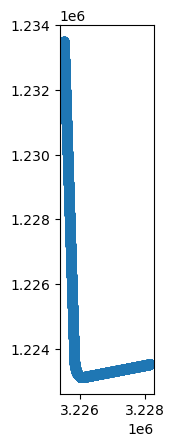

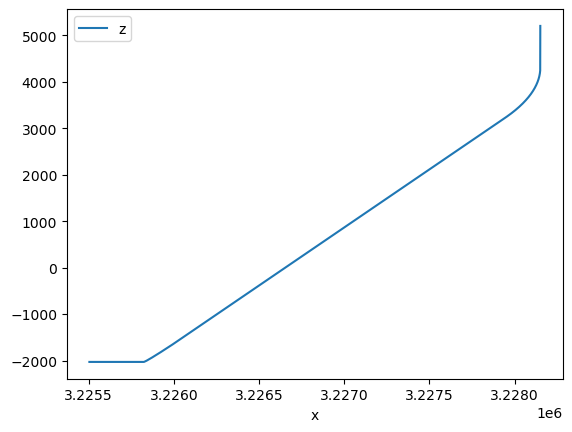

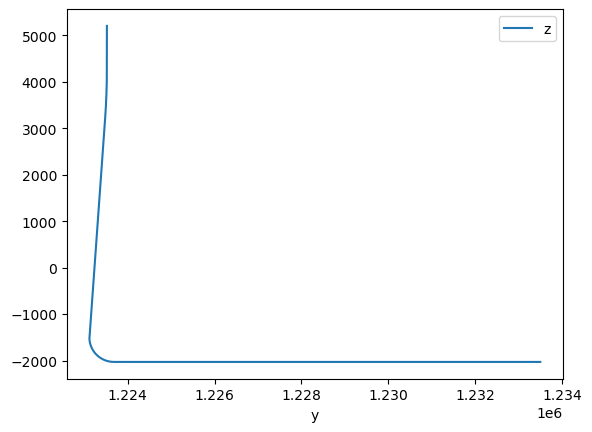

In [9]:
## Add referenced data from survey
crs = 'EPSG:2231'
xy = wells[wells.Well_Title.str.contains('20-17-1NAH Wakeman')].geometry.values[0].xy
x0,y0 = [p[0] for p in xy]

kb = 5201.0
gl = 5185.0

df['x'] = df['E'] + x0
df['y'] = df['N'] + y0
df['z'] = kb - df['TVD'] #always confirm the MD reference of the survey!!!

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y, df.z), crs=crs)

# Preview Data
gdf.plot()
df.plot(x='x',y='z')
df.plot(x='y',y='z')
gdf.head(2)

<Axes: >

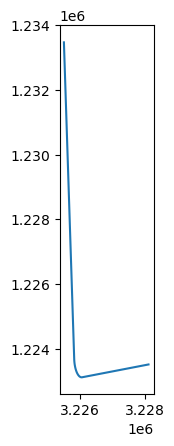

In [10]:
## Make a LineString version
linegdf = gdf[:1].copy()
linegdf['geometry'] = LineString(gdf.geometry)
linegdf.plot()

In [ ]:
## Save Out Data
gdf.to_file('./data/20-17-1NAH_Wakeman_devsurv_pnts.gpkg')
linegdf.to_file('./data/20-17-1NAH_Wakeman_devsurv_line.gpkg')